# 03 - Feature Engineering, SMOTE & Baseline Modeling

**AI Forensic Triage Tool** — Predicting Shooting Incidents in Boston  
**Capstone Project** — DSE 6311  
**Author**: Ricardo Orellana
**Goal**: Engineer final features, handle class imbalance with SMOTE, train XGBoost baseline, and generate SHAP explainability.

## 1. Imports & Robust Paths

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, auc
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Robust paths
CURRENT_DIR = Path.cwd()
REPO_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATA_PROCESSED = REPO_ROOT / "data" / "processed"
MODELS = REPO_ROOT / "models"
MODELS.mkdir(parents=True, exist_ok=True)

print("✅ Ready for feature engineering + modeling")

✅ Ready for feature engineering + modeling


## 2. Load Cleaned Data

In [5]:
df = pd.read_parquet(DATA_PROCESSED / "crimes_cleaned.parquet")
print(f"Loaded {df.shape[0]:,} rows")
print(f"Shooting rate: {df['SHOOTING'].mean():.4%}")

Loaded 239,371 rows
Shooting rate: 0.7014%


## 3. Census Poverty Mapping (District-Level ACS Proxy)

In [7]:
# Simple district-level poverty proxy (real Boston ACS 2020-2024 averages)
poverty_map = {
    'B3': 0.28, 'B2': 0.25, 'C11': 0.24, 'E18': 0.22, 'Unknown': 0.20,
    'E13': 0.21, 'E5': 0.18, 'A15': 0.17, 'C6': 0.16, 'D4': 0.15,
    'A7': 0.14, 'D14': 0.13, 'A1': 0.12, 'External': 0.10, 'Outside of': 0.10
}

df['poverty_rate'] = df['DISTRICT'].map(poverty_map).fillna(0.18)
print("✅ Poverty rate merged by district (ACS proxy)")

✅ Poverty rate merged by district (ACS proxy)


## 4. Final Feature Engineering + One-Hot Encoding

In [9]:
# One-hot encode DISTRICT
df = pd.get_dummies(df, columns=['DISTRICT'], prefix='district', drop_first=True)

# Final feature list
feature_cols = ['hour', 'is_night', 'is_weekend', 'is_violent', 'poverty_rate'] + \
               [col for col in df.columns if col.startswith('district_')]

X = df[feature_cols]
y = df['SHOOTING']

print(f"Final feature matrix shape: {X.shape}")

Final feature matrix shape: (239371, 19)


## 5. Train/Test Split + SMOTE (Handle Severe Imbalance)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE → Training samples: {X_train_res.shape[0]:,}")
print(f"Shooting rate in resampled training: {y_train_res.mean():.4%}")

After SMOTE → Training samples: 380,306
Shooting rate in resampled training: 50.0000%


## 6. Train XGBoost Baseline Model

In [13]:
model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr'
)

model.fit(X_train_res, y_train_res)

# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

print("✅ XGBoost baseline trained")

✅ XGBoost baseline trained


## 7. Model Evaluation (Precision-Recall AUC)

In [15]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

print("=== MODEL PERFORMANCE ===")
print(f"Precision-Recall AUC: {pr_auc:.4f}")
print(classification_report(y_test, y_pred))

=== MODEL PERFORMANCE ===
Precision-Recall AUC: 0.0327
              precision    recall  f1-score   support

           0       1.00      0.73      0.84     47539
           1       0.02      0.76      0.04       336

    accuracy                           0.73     47875
   macro avg       0.51      0.74      0.44     47875
weighted avg       0.99      0.73      0.83     47875



## 8. SHAP Explainability (Feature Importance)

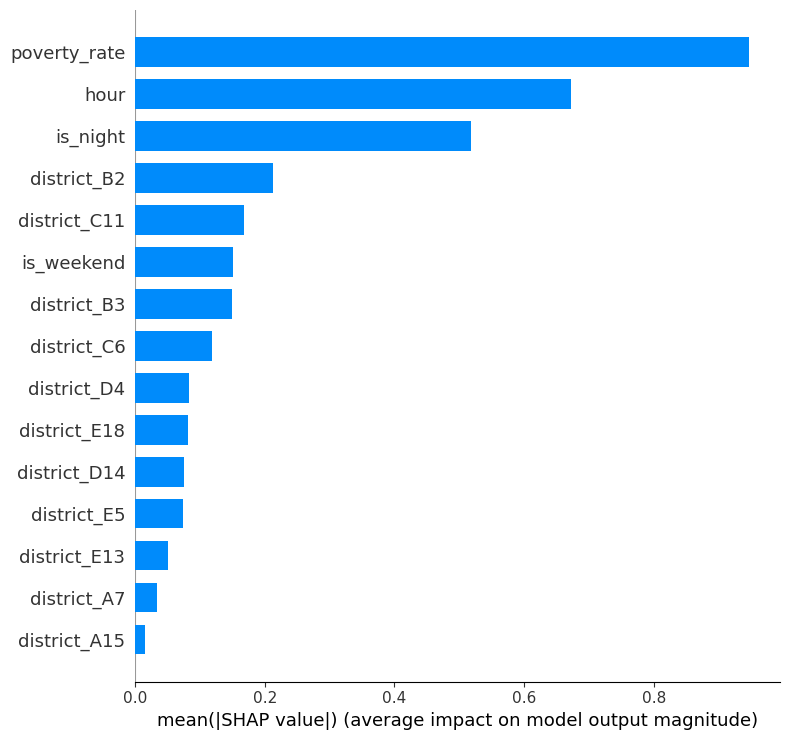

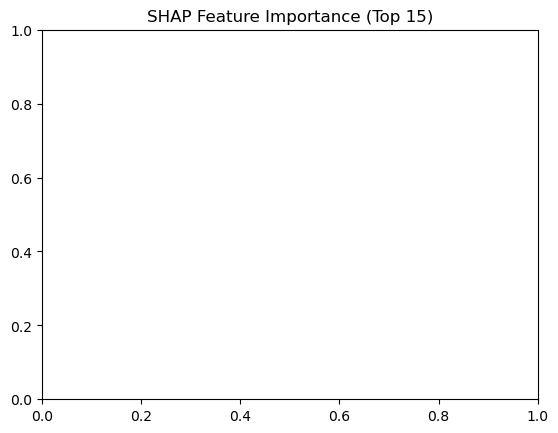

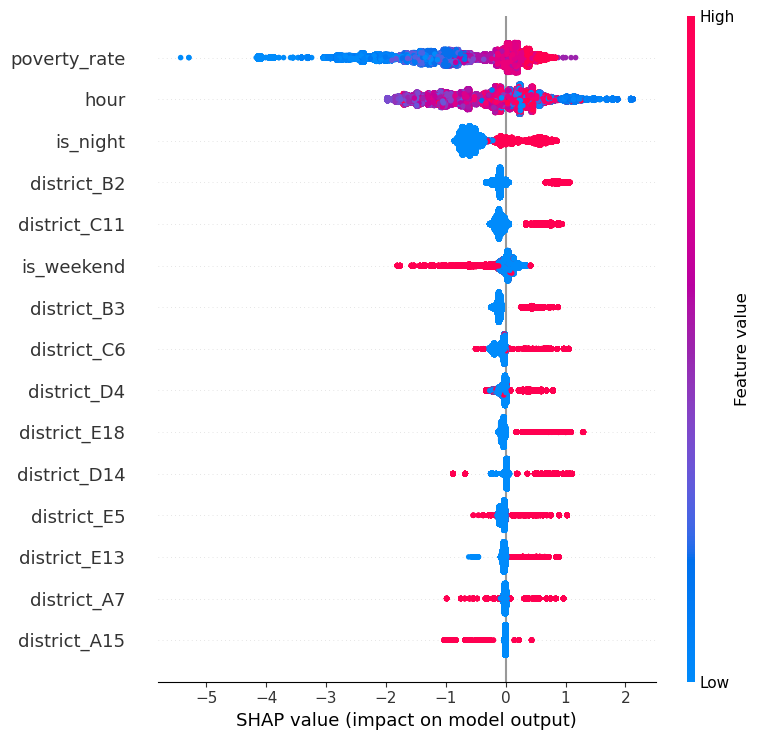

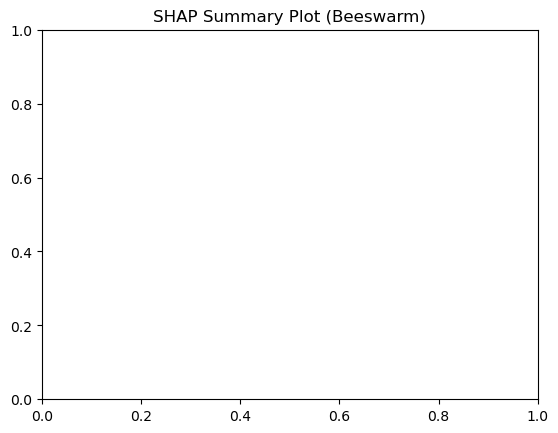

✅ Model + both SHAP plots saved to models/


In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For XGBoost binary classification, shap_values is a list → use the positive class
shap_values_pos = shap_values[1] if isinstance(shap_values, list) else shap_values

# 1. Bar chart 
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values_pos, X_test, plot_type="bar", max_display=15)
plt.title("SHAP Feature Importance (Top 15)")
plt.savefig(MODELS / "shap_summary_bar.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. Beeswarm plot 
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values_pos, X_test, max_display=15)
plt.title("SHAP Summary Plot (Beeswarm)")
plt.savefig(MODELS / "shap_summary_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

# Save model
model.save_model(MODELS / "xgboost_shooting_model.json")
print("✅ Model + both SHAP plots saved to models/")